In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from typing import TypedDict, Annotated, Optional
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, SystemMessage
from langgraph.graph.message import add_messages  ## Optimized reducer with BaseMessage Class
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
from my_llm import *
from langchain_core.runnables import RunnableConfig
import sqlite3
import operator
from IPython.display import display, Image

from pydantic import BaseModel, Field

In [2]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(description="What to cover")

class Plan(BaseModel):
    blog_title: str = Field(description="Blog Title in less than 10 words")
    tasks: list[Task] = Field(description="List of tasks to cover in the blog")


In [13]:
class State(TypedDict):
    topic: str
    plan: Plan ## Created by Orchestrator Agent
    sections : Annotated[list[tuple], operator.add] = Field(description="Stores the output of worker nodes for the tasks provided") ## Created by Orchestrator Agent, we have added a reducer function to it which will add the output of worker nodes to this list
    final: str = Field(description="Final blog content created by Orchestrator Agent")
    approved: Optional[bool] = Field(description="Approval status of the final blog content")
    feedback: Optional[str] = Field(description="Feedback provided by the user in case the content is not approved")

In [ ]:
def Orchestrator(state: State):

    message = [SystemMessage(content="Create a blog plan with 5-7 sections on the following topic."), 
               HumanMessage(content=f"Topic: {state['topic']}")]
    plan = model.with_structured_output(Plan).invoke(
        message
    )
    return {"plan": plan}


def UserFeedback(state: State):
    print("\nGenerated Plan:\n", state["plan"])
    
    user_input = input(
        "\nType:\n"
        "- 'yes' to approve\n"
        "- 'no' to retry\n"
        "- OR give feedback (what to add/remove/change):\n"
    )
    
    if user_input.lower() == "yes":
        return {"approved": True, "feedback": None}
    if user_input.lower() == "no":
        return {"approved": False, "feedback": None}
    else:
        print("\nUser Feedback:\n", user_input)
        return {"approved": False, "feedback": user_input}
    

def RefinePlan(state: State):
    message = [
        SystemMessage(content="Improve the blog plan based on user feedback."),
        HumanMessage(content=f"""
        Original Topic: {state['topic']}
        
        Current Plan:
        {state['plan']}
        
        User Feedback:
        {state['feedback']}
        
        Modify the plan accordingly. If user feedback is null, try to improve the plan by trying again.
        """)
    ]
    
    new_plan = model.with_structured_output(Plan).invoke(message)
    
    return {"plan": new_plan}

def route_after_feedback(state):
    if state["approved"]:
        return fanout_section_writing(state)  # ✅ returns Send list
    else:
        return "refine"


def fanout_section_writing(state: State):
    return [
        Send("worker", {
            "task": task,
            "topic": state["topic"],
            "plan": state["plan"],
            "index": i  # ✅ IMPORTANT
        })
        for i, task in enumerate(state["plan"].tasks)
    ]


def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    index = payload["index"]
    
    message = [
        SystemMessage(content="Write a clean Markdown section for a blog."),
        HumanMessage(content=f"""
Blog Topic: {topic}
Blog Title: {plan.blog_title}
Task Title: {task.title}
Task Brief: {task.brief}

Return only the section content in Markdown. Use ## for the task title and do not mention about the blog title in the section content.
""")
    ]
    
    section_content = model.invoke(message).content.strip()
    
    return {"sections": [(index, section_content)]}  # ✅ FIX

from pathlib import Path

def reducer(state: State) -> State:
    title = state["plan"].blog_title
    
    # ✅ Sort sections by index
    sorted_sections = sorted(state["sections"], key=lambda x: x[0])
    
    ordered_content = [content for _, content in sorted_sections]
    
    body = "\n\n".join(ordered_content).strip()

    final_content = f"# {title}\n\n{body}"

    folder = "./generated_articles"

    file_name = title.lower().replace(" ", "_") + ".md"
    output_path = Path(folder)/file_name
    output_path.parent.mkdir(exist_ok=True)

    output_path.write_text(final_content, encoding="utf-8")

    return {"final": final_content}

In [23]:
graph = StateGraph(State)

graph.add_node("orchestrator", Orchestrator)
graph.add_node("user_feedback", UserFeedback)
graph.add_node("refine", RefinePlan)

graph.add_node("worker", worker)
graph.add_node("reducer", reducer)
graph.add_node("fanout", fanout_section_writing)

graph.set_entry_point("orchestrator")

# Plan → feedback
graph.add_edge("orchestrator", "user_feedback")

graph.add_conditional_edges(
    "user_feedback",
    route_after_feedback
)

graph.add_edge("refine", "user_feedback")

# Workers → reducer
graph.add_edge("worker", "reducer")

# End
graph.add_edge("reducer", END)

workflow = graph.compile()

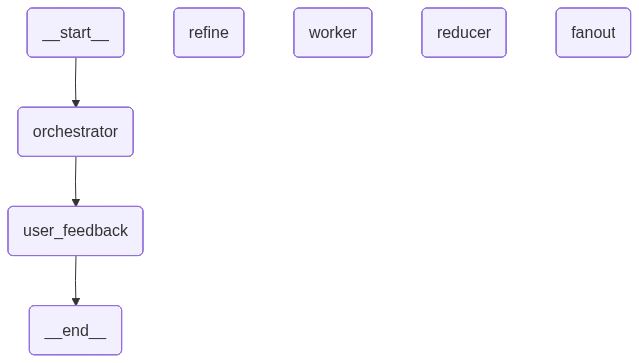

In [24]:
display(Image(workflow.get_graph().draw_mermaid_png()))

In [27]:
workflow.invoke({'topic': 'what is Agent to agent protocol?'})


Generated Plan:
 blog_title='Agent-to-Agent Protocol Explained' tasks=[Task(id=1, title='Introduction to Agent Communication', brief='Define agents and basic communication protocols to set context for agent-to-agent interactions.'), Task(id=2, title='Overview of Agent-to-Agent Protocol', brief='Explain what an agent-to-agent protocol is and why it is important in decentralized systems.'), Task(id=3, title='How the Protocol Works', brief='Dive into the technical aspects: communication flow, key components, message exchange formats, and architecture.'), Task(id=4, title='Applications and Use Cases', brief='Discuss real-world scenarios and industries that benefit from implementing agent-to-agent protocols.'), Task(id=5, title='Benefits and Challenges', brief='Highlight the advantages of agent-to-agent protocols, along with limitations and potential issues in implementation.'), Task(id=6, title='Future Trends and Conclusion', brief='Summarize key points and explore emerging trends and fut

c:\Users\shivo\Projects\Agentic\Agentic_Learning\langenv\lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(blog_title='Agent-to...unication protocols.')]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(



User Feedback:
 its related to AI

Generated Plan:
 blog_title='Agent-to-Agent Protocol in AI' tasks=[Task(id=1, title='Introduction to AI Agents', brief='Define AI agents and their role, providing context on agent communication in intelligent systems.'), Task(id=2, title='Overview of Agent-to-Agent Protocol', brief='Explain what an agent-to-agent protocol is, emphasizing its significance in AI-driven decentralized and multi-agent environments.'), Task(id=3, title='How the Protocol Works in AI Systems', brief='Examine the technical details of agent communication in AI, covering message exchange formats, architectures, and the impact on decision making.'), Task(id=4, title='AI Applications and Use Cases', brief='Discuss real-world AI scenarios that leverage agent-to-agent protocols, such as autonomous vehicles, smart grids, and distributed learning environments.'), Task(id=5, title='Benefits and Challenges in AI Context', brief='Highlight the advantages of implementing agent-to-agent p

c:\Users\shivo\Projects\Agentic\Agentic_Learning\langenv\lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(blog_title='Agent-to...ficial intelligence.')]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


{'topic': 'what is Agent to agent protocol?',
 'plan': Plan(blog_title='Agent-to-Agent Protocol in AI', tasks=[Task(id=1, title='Introduction to AI Agents', brief='Define AI agents and their role, providing context on agent communication in intelligent systems.'), Task(id=2, title='Overview of Agent-to-Agent Protocol', brief='Explain what an agent-to-agent protocol is, emphasizing its significance in AI-driven decentralized and multi-agent environments.'), Task(id=3, title='How the Protocol Works in AI Systems', brief='Examine the technical details of agent communication in AI, covering message exchange formats, architectures, and the impact on decision making.'), Task(id=4, title='AI Applications and Use Cases', brief='Discuss real-world AI scenarios that leverage agent-to-agent protocols, such as autonomous vehicles, smart grids, and distributed learning environments.'), Task(id=5, title='Benefits and Challenges in AI Context', brief='Highlight the advantages of implementing agent-to